# Plot Ground State PEC

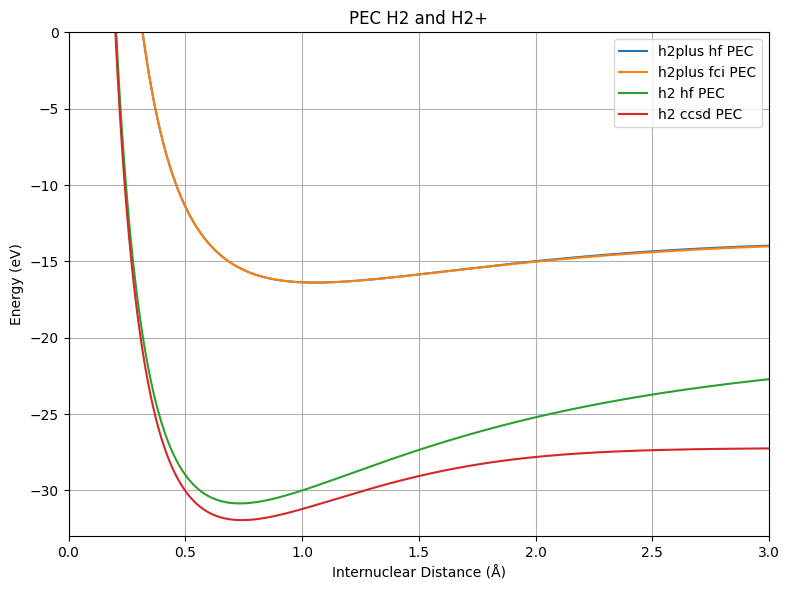

In [115]:
#Plot Potential Energy Curves

import csv
import numpy as np
import matplotlib.pyplot as plt
import os


molecules = ["h2plus", "h2plus", "h2", "h2"]#, "h2"]     #molecule, h2 or h2+
methods = ["hf", "fci", "hf", "ccsd"]#, "fci"]           #method, hf, ccsd, fci

files = []                                             #empty list for files

#add files to list
for i in range (0, len(molecules)):
    file = f"{molecules[i]}_{methods[i]}_pec.csv"
    files.append(file)
    
#function to read file
def read_two_col_csv(path):                                      
    R, E = [], []                               #create empty lists to hold distances and energies
    with open(path, "r", newline="") as f:      #open file
        reader = csv.reader(f)                  #create object to read file
        _ = next(reader)  # header              #skips header row
        for row in reader:
            if not row:
                continue
            R.append(float(row[0]))             #add R to list
            E.append(float(row[1]))             #add each E to list
    return np.array(R), np.array(E)             #return lists as arrays

R = []
E = []

hartree_to_ev = 27.211396                      #conversion factor

for i in range(0,len(molecules)):
    r, e = read_two_col_csv(files[i])           #read each file
    #e -= e.min()                                #shift each pec to 0
    e = e * hartree_to_ev                       #change units from hartree to ev
    R.append(r)                                 #add r to list
    E.append(e)                                 #add e to list

#make plot
plt.figure(figsize=(8,6))                   

#plot each pec
for i in range(0,len(molecules)):
    plt.plot(R[i], E[i], linestyle = "-", label = f"{molecules[i]} {methods[i]} PEC")
    
plt.xlabel("Internuclear Distance (Å)")
plt.ylabel("Energy (eV)")
plt.title("PEC H2 and H2+")
plt.xlim(0,3)
plt.ylim(-33, 0)
plt.grid(True)
plt.legend()
plt.tight_layout()

#save image
save_pdf = os.path.join("Ground State Plots", f"{molecules}, {methods}.pdf")
save_png = os.path.join("Ground State Plots", f"{molecules}, {methods}.png")

plt.savefig(save_pdf, bbox_inches='tight')          # BEST for poster
plt.savefig(save_png, dpi=600, bbox_inches='tight') # backup
plt.show()

